# 06 – SNR Mitigation Strategies

In this notebook, I explore methods to mitigate the influence of low signal-to-noise ratio (SNR) spectra on autoencoder training and latent space structure. This step is motivated by the observation that SNR correlates strongly with several latent components.

The first part is to **remove poor-quality observations** and improve robustness. This includes:

- Filtering spectra with extreme SNR values using a 3σ rule
- Saving a cleaned metadata table
- Preparing data for re-training

## Goals

- Implement **SNR-weighted loss functions** (give more weight to reliable spectra).
- Apply **SNR decorrelation penalties** to encourage latent vectors to be independent of SNR.
- Test **latent space normalization** to remove scale-based SNR effects.

Each method can be toggled individually or in combination and with different values.

In addition to these main methods, I added the option to add gaussian noise with the option to modify its standard deviation. Other things, I added to the architecture were random dropouts at different sizes and after different layers. Also adjusting epochs.

The total loss looks like:

$$\text{Total Loss} = \text{Weighted MSE} + \alpha \cdot \text{Decorrel. Penalty}$$

In the last part I will try to predict activity indicators from latent space.

---

## Setup

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, losses, backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import os
import random
from astropy.io import fits
import umap
import seaborn as sns
from scipy.stats import spearmanr

**Setting up tenserflow's internal determinism:**

I set it up in such way that with the same seed all outputs can be exactly reproduced.

In [52]:
np.random.seed(42)
tf.random.set_seed(42)

seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

tf.config.experimental.enable_op_determinism()

In [53]:
metadata_path = "../outputs/aligned_metadata/aligned_metadata.csv"
df = pd.read_csv(metadata_path)

print("Loaded metadata shape:", df.shape)
df.head()

Loaded metadata shape: (95, 13)


,BJD,RV,FWHM,CONTRAST,BIS,RV_err,FWHM_err,CONTRAST_err,BIS_err,HALPHA,SNR_25,SNR_46,SNR_47
0,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974,2.69504,50.104,14.105,13.335
1,2.458679e+06,-5.328574,12.673912,10.063694,0.306980,0.012692,0.077585,0.048857,0.034974,2.70468,51.253,11.739,10.940
2,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669,3.53532,98.046,25.750,23.613
3,2.458680e+06,-5.008305,12.220235,7.271535,-0.081408,0.009027,0.064395,0.030526,0.022669,3.70245,99.969,26.002,23.719
4,2.458681e+06,-5.048751,12.359634,9.902224,-0.103738,0.007096,0.055803,0.035579,0.018071,3.08575,93.477,14.924,12.876


### 3σ Filtering Based on SNR Columns

I identify all SNR-related columns and remove observations where any SNR value deviates more than ±3 standard deviations from the mean.

In [54]:
snr_columns = [col for col in df.columns if "SNR" in col]

filter_info = {}
for col in snr_columns:
    mean = df[col].mean()
    std = df[col].std()
    low, high = mean - 3 * std, mean + 3 * std
    filter_info[col] = (low, high)

mask = np.ones(len(df), dtype=bool)
for col, (lo, hi) in filter_info.items():
    mask &= df[col].between(lo, hi)

df_filtered = df[mask].reset_index(drop=True)
print(f"Removed {len(df) - len(df_filtered)} outliers")

Removed 0 outliers


#### Export Cleaned Metadata

I save the filtered metadata for further use in training and evaluation.

In [55]:
os.makedirs("../outputs/aligned_metadata", exist_ok=True)
df_filtered.to_csv("../outputs/aligned_metadata/aligned_metadata_snr_filtered.csv", index=False)

print("Saved filtered metadata to aligned_metadata_snr_filtered.csv")

Saved filtered metadata to aligned_metadata_snr_filtered.csv


### Loading Spectral Data

In [56]:
fits_root = "../../aumicAE1"
with open("../data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = [os.path.join(fits_root, line.strip().lstrip("../")) for line in f if line.strip()]

# Select spectral orders
selected_orders = [25, 46, 47]

def load_multi_order_stack(file_path, order_indices):
    with fits.open(file_path) as hdul:
        spec = hdul["SPEC"].data
        cont = hdul["CONT"].data

        stacked = []
        for order in order_indices:
            flux = spec[order, :]
            continuum = cont[order, :]
            continuum = np.where(np.isfinite(continuum) & (continuum > 1e-3), continuum, 1.0)
            norm = flux / continuum
            norm = np.nan_to_num(norm, nan=0.0, posinf=5.0, neginf=0.0)
            norm = np.clip(norm, 0.0, 5.0)
            stacked.append(norm.astype(np.float32))

        return np.stack(stacked, axis=-1)

# Build input tensor X
spectra = [load_multi_order_stack(f, selected_orders) for f in vis_a_files]
X = np.stack(spectra)
print("X shape:", X.shape)  # Should be (n_samples, 4096, 3)

X shape: (95, 4096, 3)


### Load SNR_25 from FITS headers

In [57]:
snr_values = []

for file in vis_a_files:
    with fits.open(file) as hdul:
        header = hdul[0].header
        snr = header.get("HIERARCH CARACAL FOX SNR 30", np.nan)
        snr_values.append(snr)

SNR_25 = np.array(snr_values)
snr_norm = (SNR_25 - np.mean(SNR_25)) / np.std(SNR_25)

### **METHOD AND LATENT-DIMENSION SELECTION**

In [ ]:
LATENT_DIM = 8
USE_WEIGHTED_LOSS = True
USE_DECORR_PENALTY = True
ALPHA_VAL = 5.0
USE_LATENT_NORM = True
USE_NOISE = False  
NOISE_STD = 0.1
EXCLUDED_DIMS = [0]
EPOCHS_NUM = 100
PATIENCE_EPOCHS = 5
ACTIVATION_FUNC = "sigmoid"
BATCH_SIZE = 8
EARLY_DROP=0.0
MID_DROP=0.0 
DEEP_DROP=0.0
LATENT_DROP=0.0
DECODER_DROP=0.0

### Adding Gaussian Noise

In [59]:
def add_gaussian_noise(X, std=0.05):
    noise = np.random.normal(loc=0.0, scale=std, size=X.shape)
    return np.clip(X + noise, 0.0, 5.0)

### **Autoencoder (Baseline)**

**Basic Architecture**

In [60]:
def build_autoencoder_base(latent_dim):
    input_layer = layers.Input(shape=(4096, 3))

    x = layers.Conv1D(16, 5, activation='relu', padding='same')(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)

    latent = layers.Dense(latent_dim, name="latent")(x)
    
    if USE_LATENT_NORM:
        latent = layers.LayerNormalization()(latent)

    x = layers.Dense(4096 * 3)(latent)
    x = layers.Reshape((4096, 3))(x)
    decoded = layers.Conv1D(3, 3, activation='linear', padding='same')(x)

    model = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, latent)
    return model, encoder

**Advanced Architecture**

In [61]:
def build_autoencoder(latent_dim):
    input_layer = layers.Input(shape=(4096, 3))

    # Encoder
    x = layers.Conv1D(16, 5, activation='relu', padding='same')(input_layer)
    x = layers.BatchNormalization()(x) # immproves the performance 
    x = layers.Dropout(EARLY_DROP)(x)
    x = layers.MaxPooling1D(4)(x)

    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
    x = layers.Dropout(MID_DROP)(x) 
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
    x = layers.Dropout(DEEP_DROP)(x) 
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Flatten()(x)

    latent = layers.Dense(latent_dim, name="latent")(x)
    latent = layers.Dropout(LATENT_DROP)(latent) 
    if USE_LATENT_NORM:
        latent = layers.LayerNormalization()(latent)

    # Decoder
    x = layers.Dense(256 * 8, activation='relu')(latent)
    x = layers.Reshape((256, 8))(x)

    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)
    x = layers.Dropout(DECODER_DROP)(x) 

    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(8, 3, activation='relu', padding='same')(x)

    x = layers.UpSampling1D(4)(x)
    decoded = layers.Conv1D(3, 3, activation=ACTIVATION_FUNC, padding='same')(x)

    model = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, latent)
    return model, encoder


## 1. SNR-Weighted Loss Function

Each sample will contribute to the loss based on its signal quality.
Higher SNR → higher weight → more influence during training.

We have a *weighted MSE LOSS*.

This is done in the training loop (class):

```
if self.use_weighted_loss:
    loss_recon = tf.reduce_mean(recon_error * snr_weights_batch)
```

## 2. Latent–SNR Decorrelation Penalty

I penalize strong correlation between latent vectors and SNR.

This pushes the model to encode variability unrelated to signal quality.

We can penalize SNR correlation for a **subset of latent dimensions** (optional).
    
*Parameters:*

- **latent_output**: Tensor of shape (batch_size, latent_dim)
- **snr_tensor**: Tensor of shape (batch_size,)
- **alpha**: Penalty strength
- **exclude_dims**: List of latent dims to exclude from penalty (e.g. [0])

*Returns:*

- Scalar tensor penalty

In [62]:
def partial_correlation_penalty(latent_output, snr_tensor, alpha=0.1, exclude_dims=None):
    latent_mean = tf.reduce_mean(latent_output, axis=0)
    snr_mean = tf.reduce_mean(snr_tensor)

    latent_centered = latent_output - latent_mean
    snr_centered = snr_tensor - snr_mean

    corr_numer = tf.reduce_sum(latent_centered * tf.expand_dims(snr_centered, axis=1), axis=0)
    corr_denom = tf.sqrt(tf.reduce_sum(tf.square(latent_centered), axis=0)) * tf.sqrt(tf.reduce_sum(tf.square(snr_centered)))
    correlation = corr_numer / (corr_denom + 1e-6)

    if exclude_dims is not None:
        mask = tf.ones_like(correlation)
        mask_numpy = np.ones(mask.shape, dtype=bool)
        mask_numpy[exclude_dims] = False
        mask = tf.constant(mask_numpy, dtype=tf.float32)
        correlation = correlation * mask

    penalty = alpha * tf.reduce_mean(tf.square(correlation))
    return penalty

For Post-hoc (this is simpler but worse for generalization):

In [63]:
def compute_snr_latent_correlation(latents, snr):
    latents = (latents - tf.reduce_mean(latents, axis=0)) / tf.math.reduce_std(latents, axis=0)
    snr = (snr - tf.reduce_mean(snr)) / tf.math.reduce_std(snr)
    corr = tf.reduce_mean(latents * tf.expand_dims(snr, -1), axis=0)
    return tf.reduce_mean(tf.square(corr))

## 3. Normalize Latent Vectors

Post-training, I normalize the latent vectors (e.g., Z-score) to mitigate residual trends related to signal intensity or SNR artifacts.

In [64]:
def normalize_latent(latent):
    mean = np.mean(latent, axis=0)
    std = np.std(latent, axis=0) + 1e-6
    return (latent - mean) / std

### **Training Loop**

In [65]:
class SNRTrainer(tf.keras.Model):
    def __init__(self, autoencoder, latent_layer_name="latent", alpha=0.1, exclude_dims=None,
                 use_weighted_loss=False, use_decorrelation=False):
        super().__init__()
        self.autoencoder = autoencoder
        self.latent_layer = autoencoder.get_layer(latent_layer_name).output
        self.encoder = tf.keras.Model(autoencoder.input, self.latent_layer)
        self.alpha = alpha
        self.exclude_dims = exclude_dims
        self.use_weighted_loss = use_weighted_loss
        self.use_decorrelation = use_decorrelation

    def compile(self, optimizer):
        super().compile()
        self.optimizer = optimizer

    def train_step(self, data):
        X_batch, snr_raw = data

        # Normalize and clip SNR weights to ensure positive and stable contribution
        snr_weights_batch = snr_raw / (tf.reduce_mean(snr_raw) + 1e-6)
        snr_weights_batch = tf.clip_by_value(snr_weights_batch, clip_value_min=0.1, clip_value_max=10.0)

        with tf.GradientTape() as tape:
            recon = self.autoencoder(X_batch, training=True)
            latent = self.encoder(X_batch, training=True)

            recon_error = tf.reduce_mean(tf.square(X_batch - recon), axis=[1, 2])  # (batch_size,)

            if self.use_weighted_loss:
                loss_recon = tf.reduce_mean(recon_error * snr_weights_batch)
            else:
                loss_recon = tf.reduce_mean(recon_error)

            if self.use_decorrelation:
                loss_corr = partial_correlation_penalty(
                    latent, snr_weights_batch, alpha=self.alpha, exclude_dims=self.exclude_dims
                )
            else:
                loss_corr = tf.constant(0.0, dtype=tf.float32)

            total_loss = loss_recon + loss_corr

        grads = tape.gradient(total_loss, self.autoencoder.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.autoencoder.trainable_variables))

        return {
            "loss": total_loss,
            "recon_loss": loss_recon,
            "decorrelation_penalty": loss_corr
        }

### Create and Compile Trainer

In [66]:
X_input = add_gaussian_noise(X, NOISE_STD).astype(np.float32) if USE_NOISE else X.astype(np.float32)
snr_tensor = tf.convert_to_tensor(snr_norm[:len(X_input)], dtype=tf.float32)

autoencoder, encoder = build_autoencoder(LATENT_DIM)
trainer = SNRTrainer(
    autoencoder,
    alpha=ALPHA_VAL,
    exclude_dims=EXCLUDED_DIMS,
    use_weighted_loss=USE_WEIGHTED_LOSS,
    use_decorrelation=USE_DECORR_PENALTY
)
trainer.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

### Dataset + Training

In [67]:
dataset = tf.data.Dataset.from_tensor_slices((X_input, snr_tensor))
dataset = dataset.shuffle(buffer_size=len(X_input)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE) # lets TensorFlow dynamically choose the optimal number of batches to prefetch based on system resources (e.g. CPU/GPU load)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="recon_loss", 
    patience=PATIENCE_EPOCHS,
    restore_best_weights=True,
    mode="min"
)

trainer.fit(dataset, epochs=EPOCHS_NUM, callbacks=[early_stopping], verbose=2)

Epoch 1/100
12/12 - 2s - 170ms/step - decorrelation_penalty: 0.1445 - loss: 0.8022 - recon_loss: 0.6577
Epoch 2/100
12/12 - 0s - 13ms/step - decorrelation_penalty: 0.1873 - loss: 0.4580 - recon_loss: 0.2707
Epoch 3/100
12/12 - 0s - 14ms/step - decorrelation_penalty: 0.6852 - loss: 1.0664 - recon_loss: 0.3813
Epoch 4/100
12/12 - 0s - 13ms/step - decorrelation_penalty: 0.4138 - loss: 0.5661 - recon_loss: 0.1522
Epoch 5/100
12/12 - 0s - 12ms/step - decorrelation_penalty: 1.7832 - loss: 1.9145 - recon_loss: 0.1313
Epoch 6/100
12/12 - 0s - 12ms/step - decorrelation_penalty: 0.5850 - loss: 0.7040 - recon_loss: 0.1190
Epoch 7/100
12/12 - 0s - 13ms/step - decorrelation_penalty: 0.0737 - loss: 0.0902 - recon_loss: 0.0165
Epoch 8/100
12/12 - 0s - 12ms/step - decorrelation_penalty: 0.1134 - loss: 0.1351 - recon_loss: 0.0217
Epoch 9/100
12/12 - 0s - 12ms/step - decorrelation_penalty: 3.3812 - loss: 3.3833 - recon_loss: 0.0021
Epoch 10/100
12/12 - 0s - 13ms/step - decorrelation_penalty: 0.5376 - lo

### Save Latents for Analysis

In [68]:
Z = encoder.predict(X)
if USE_LATENT_NORM:
    Z = normalize_latent(Z)

np.save("../outputs/latent/latent_vectors_snr_mitigated.npy", Z)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


2025-04-21 20:59:44.897819: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


### Decorrelated Latent Space

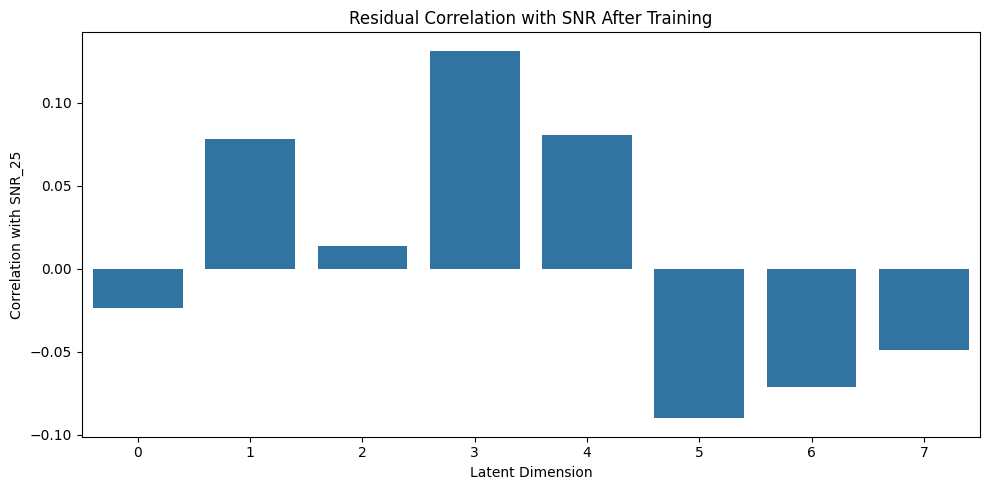

In [69]:
corrs = [np.corrcoef(Z[:, i], snr_norm[:len(Z)])[0, 1] for i in range(Z.shape[1])]
plt.figure(figsize=(10, 5))
sns.barplot(x=np.arange(len(corrs)), y=corrs)
plt.xlabel("Latent Dimension")
plt.ylabel("Correlation with SNR_25")
plt.title("Residual Correlation with SNR After Training")
plt.tight_layout()
plt.show()

### UMAP Projection Colored by SNR

Even after training with decorrelation penalties, I assess whether the UMAP embedding of the latent space still shows patterns related to signal-to-noise ratio.

I use the same latent vectors and project them into 2D using UMAP, then color each point by the corresponding `SNR_25` value.

If UMAP shows a strong gradient or clustering by SNR, this indicates residual correlation at a global level.

(95, 8) 95


/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


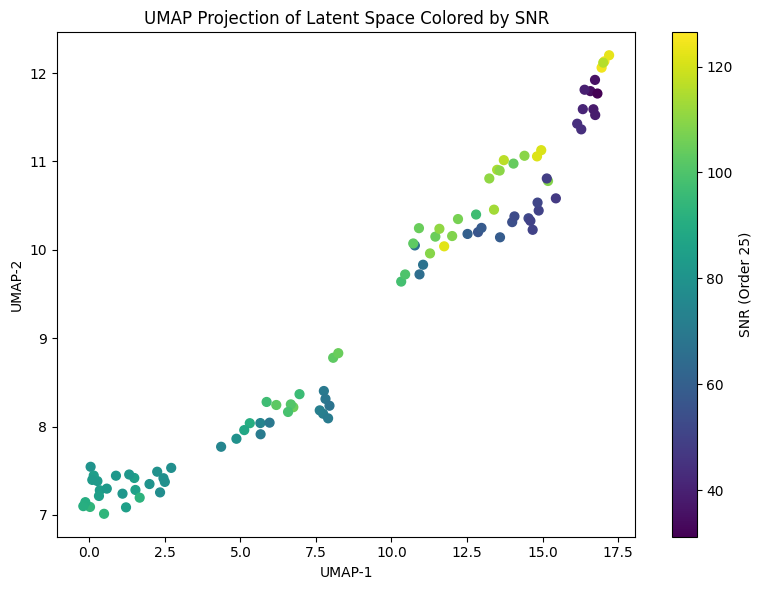

In [70]:
print(Z.shape, len(SNR_25))

# Project latent space to 2D
reducer = umap.UMAP(random_state=42)
Z_umap = reducer.fit_transform(Z)

# Plot UMAP with SNR coloring
plt.figure(figsize=(8, 6))
sc = plt.scatter(Z_umap[:, 0], Z_umap[:, 1], c=SNR_25[:len(Z_umap)], cmap='viridis', s=40)
plt.colorbar(sc, label="SNR (Order 25)")
plt.title("UMAP Projection of Latent Space Colored by SNR")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

### Spearman Correlation

The Spearman correlation is a statistical measure that captures the strength and direction of a monotonic relationship between two variables - even if that relationship is nonlinear.

Values should be close to 0.

In [71]:
corr_umap1, _ = spearmanr(Z_umap[:, 0], SNR_25[:len(Z_umap)])
corr_umap2, _ = spearmanr(Z_umap[:, 1], SNR_25[:len(Z_umap)])

print(f"Spearman corr with UMAP-1: {corr_umap1:.3f}")
print(f"Spearman corr with UMAP-2: {corr_umap2:.3f}")

Spearman corr with UMAP-1: -0.123
Spearman corr with UMAP-2: -0.025


## Correlation Matrix: Latent Space vs. Activity Indicators

I now compute the Pearson correlation matrix between each **latent dimension** and each **stellar activity indicator** (RV, BIS, FWHM, CONTRAST, HALPHA, etc.).

This reveals which latent dimensions are most sensitive to activity-induced spectral variability, and helps identify meaningful structure in the learned latent space.

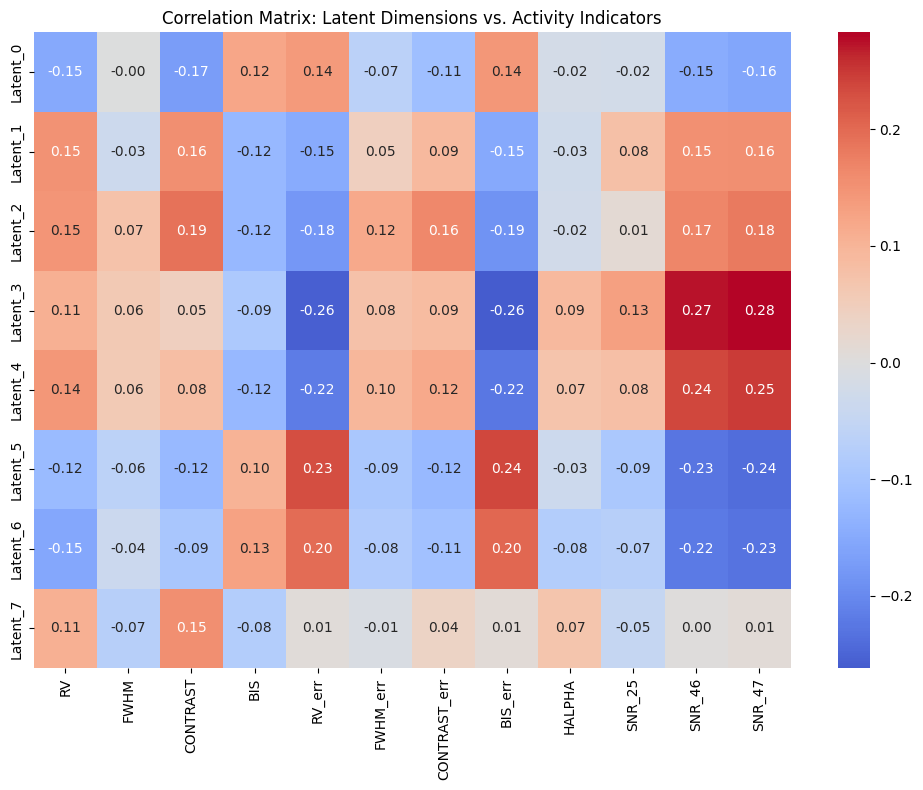

In [72]:
# Combine latent vectors with metadata
latent_df = pd.DataFrame(Z, columns=[f"Latent_{i}" for i in range(Z.shape[1])])
combined_df = pd.concat([latent_df, df_filtered.reset_index(drop=True)], axis=1)

# Select only relevant activity indicators
activity_cols = ['RV', 'FWHM', 'CONTRAST', 'BIS', 'RV_err', 'FWHM_err', 'CONTRAST_err', 'BIS_err',
                'HALPHA', 'SNR_25', 'SNR_46', 'SNR_47']
corr_matrix = combined_df[[f"Latent_{i}" for i in range(Z.shape[1])] + activity_cols].corr()
corr_subset = corr_matrix.loc[[f"Latent_{i}" for i in range(Z.shape[1])], activity_cols]

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Latent Dimensions vs. Activity Indicators")
plt.tight_layout()
plt.show()

We see that we can succefully achieve the goal of decorrelating from SNR. Note, that this has been done just based on the focus of SNR_25.

---

## Predicting Activity Indicators from Latent Space

Now that I've trained a denoised and SNR-decorrelated autoencoder, I test whether the latent vectors capture real stellar activity.

Specifically, I predict physical indicators (RV, FWHM, BIS, etc.) from the latent representation using a simple regression model.

In [73]:
# Flatten latent vectors
Z_flat = Z.reshape(Z.shape[0], -1)

# Choosing the target (e.g., RV, BIS, etc.)
target = "HALPHA"  
y = df_filtered[target].values

# Train/test split
Z_train, Z_test, y_train, y_test = train_test_split(Z_flat, y, test_size=0.3, random_state=42)

# Build regression model
inputs = Input(shape=(Z_flat.shape[1],))
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
outputs = Dense(1)(x)
model = Model(inputs, outputs)

# Compile and train
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Z_train, y_train, epochs=100, batch_size=8, validation_split=0.2)

# Predict and evaluate
y_pred = model.predict(Z_test)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.0560 - mae: 2.4246 - val_loss: 4.5591 - val_mae: 2.0933
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.5713 - mae: 2.0838 - val_loss: 3.4338 - val_mae: 1.7725
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.5077 - mae: 1.7818 - val_loss: 2.6242 - val_mae: 1.4737
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6907 - mae: 1.4990 - val_loss: 1.9716 - val_mae: 1.2175
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.9786 - mae: 1.2540 - val_loss: 1.3970 - val_mae: 1.0414
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3677 - mae: 1.0518 - val_loss: 0.9255 - val_mae: 0.8363
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8696 - mae: 0.8255 - val_loss: 0.5596 - val_mae: 0.5937
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5011 - mae: 0.5755 - val_loss: 0.3352 - val_mae: 0.3641
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2875 - mae: 0.3786

2025-04-21 20:59:54.100145: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Evaluate Predictions:

In [26]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R squared Score: {r2:.3f}")
print(f"MSE: {mse:.6f}")

R squared Score: 0.093
MSE: 0.032539


### **HALPHA – Interpretation**

| Metric        | Value     | Interpretation |
|---------------|-----------|----------------|
| **R² Score**  | **0.093** | My model explains **~9.3% of the variance** in HALPHA based on the latent representation. It's not very strong yet, but it's **better than random guessing or predicting the mean**. A positive R squared means there's some useful signal. |
| **MSE**       | **0.0325** | The average squared prediction error is relatively small — especially since the same MSE on RV gave you **R squared < 0**, this suggests that **HALPHA is more predictable** from the latent space.


- My **autoencoder is starting to capture physical structure** in the spectra that reflects the Hα activity index - this is promising!
- HALPHA appears to be **embedded in the spectral variability** that the latent space captures.
- But: the **low R² suggests there’s still room to improve**, likely through:
  - better autoencoder training (denoising, dropout, weighted loss)
  - better normalization or decorrelation
  - **multi-task or semi-supervised learning** using HALPHA during training.



### Next Steps to Try:

- **Plot HALPHA against the best-correlated latent dimension** (e.g., `Latent_3`) to verify direct correlations.
- Use **multi-output regression** to jointly predict multiple indicators (e.g., HALPHA + BIS + FWHM).
- Retrain autoencoder **with a supervised objective** (e.g., reconstruct + predict HALPHA).
- Ensure **SNR is not leaking into HALPHA prediction** (i.e., decorrelation is working properly).
- Unfreeze the encoder and fine-tune everything end-to-end.